# Fe₂O₃ Redox Kinetics — PI-DeepONet Surrogate Operator

**Objective:** Learn the operator G: T → X(t) using a Physics-Informed DeepONet
trained on real Wang 2023 TGA data at 750, 850, 900°C.

**Key difference from Neural Operator Problem 5:**
- A and Ea come from Notebook 1 inverse PINN recovery (not hardcoded true values)
- Training data is real digitised Wang 2023 TGA curves (not synthetic)
- Validation uses real Wang 2023 data at 800°C (interpolation) and 950°C (extrapolation)

**Expected result:**
- PI-DeepONet generalises to 950°C better than the inverse PINN (R²=0.27)
- Data-only DeepONet fails at both unseen temperatures
- Physics constraint enables extrapolation beyond training range

## 1. Data Preparation and Experimental Context

We begin by loading experimental TGA (Thermogravimetric Analysis) data for $Fe_2O_3$ reduction. The data is split into:
- **Training:** 750&deg;C, 850&deg;C, and 900&deg;C.
- **Interpolation Validation:** 800&deg;C.
- **Extrapolation Validation:** 950&deg;C.

Key kinetic parameters ($A$ and $E_a$) used for the physics constraints were recovered from a previous Inverse PINN study.

In [ ]:
# import libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Scientific Machine Learning/PINN/My_Own_examples/Preprint_Folder/Colab Files/'

df_raw = pd.read_csv(BASE + 'combined_conversion_data_K_sec.csv')
print("Columns:", df_raw.columns.tolist())
print("Temperatures (K):", sorted(df_raw['Temperature (K)'].unique()))
print("Total rows:", len(df_raw))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columns: ['Time (s)', 'Conversion', 'Temperature (K)']
Temperatures (K): [np.float64(1023.15), np.float64(1073.15), np.float64(1123.15), np.float64(1173.15), np.float64(1223.15)]
Total rows: 997


In [ ]:
# ── Parameters recovered from Notebook 1 inverse PINN ──────────────
A_recovered  = 5.8701e-02    # s⁻¹
Ea_recovered = 24070.0       # J/mol
R            = 8.314

# Temperature normalisation range — all 5 TGA temperatures
T_min_K = 1023.15    # 750°C
T_max_K = 1223.15    # 950°C

# Training and validation splits
train_temps_K = [1023.15, 1123.15, 1173.15]   # 750, 850, 900°C
valid_temps_K  = [1073.15, 1223.15]             # 800, 950°C

# t_max per temperature — time to reach X=0.95 from raw data
t_max_per_T = {}
for T in train_temps_K + valid_temps_K:
    df_T = df_raw[np.isclose(df_raw['Temperature (K)'], T, atol=0.5)]
    if len(df_T) == 0:
        continue
    idx = df_T['Conversion'].ge(0.95).idxmax()
    if df_T.loc[idx, 'Conversion'] >= 0.95:
        t_max_per_T[T] = df_T.loc[idx, 'Time (s)']
    else:
        t_max_per_T[T] = df_T['Time (s)'].max()
    print(f"T={T-273.15:.0f}°C: t_max = {t_max_per_T[T]:.1f} s")

# Rate constant using recovered parameters
def k_func(T_K):
    return A_recovered * np.exp(-Ea_recovered / (R * T_K))

# T normalisation helper
def norm_T(T_K):
    return (T_K - T_min_K) / (T_max_K - T_min_K)

def norm_t(t_phys, T_K):
    return t_phys / t_max_per_T[T_K]

T=750°C: t_max = 444.0 s
T=850°C: t_max = 399.0 s
T=900°C: t_max = 294.0 s
T=800°C: t_max = 465.0 s
T=950°C: t_max = 330.0 s


In [ ]:
def load_sparse_data(temps_K, n_per_T=8):
    """
    Load n_per_T evenly-spaced sparse observations per temperature.
    Applies baseline correction so X(t=0) = 0 exactly.
    """
    all_tT, all_X = [], []

    for T_K in temps_K:
        df_T = df_raw[np.isclose(df_raw['Temperature (K)'], T_K, atol=0.5)].copy()
        t_end = t_max_per_T[T_K]
        df_T  = df_T[df_T['Time (s)'] <= t_end].reset_index(drop=True)

        # Baseline correction — subtract initial X so curve starts at 0
        X0 = df_T['Conversion'].iloc[0]
        df_T['Conversion'] = (df_T['Conversion'] - X0) / (1.0 - X0)
        df_T['Conversion'] = df_T['Conversion'].clip(0.0, 1.0)

        # Select n_per_T evenly-spaced indices
        indices = np.linspace(0, len(df_T)-1, n_per_T, dtype=int)
        df_sp   = df_T.iloc[indices]

        t_phys = df_sp['Time (s)'].values.reshape(-1, 1)
        X_vals = df_sp['Conversion'].values.reshape(-1, 1)

        t_norm = t_phys / t_end
        T_norm = norm_T(T_K)
        T_col  = np.full_like(t_norm, T_norm)

        all_tT.append(np.hstack([T_col, t_norm]))
        all_X.append(X_vals)

    tT = np.vstack(all_tT).astype(np.float32)
    X  = np.vstack(all_X).astype(np.float32)
    print(f"Loaded {len(tT)} sparse points ({n_per_T} per temp, {len(temps_K)} temps)")
    print(f"X range: [{X.min():.4f}, {X.max():.4f}]  ← should be [0.0, ~0.95]")
    print(f"X at t=0 per temperature: {X[::n_per_T, 0].tolist()}  ← should all be 0.0")
    return tT, X


tT_train, X_train = load_sparse_data(train_temps_K, n_per_T=8)

Loaded 24 sparse points (8 per temp, 3 temps)
X range: [0.0000, 0.9505]  ← should be [0.0, ~0.95]
X at t=0 per temperature: [0.0, 0.0, 0.0]  ← should all be 0.0


In [ ]:
def gen_collocation_points(n_T=50, n_t=50):
    """
    Collocation points sampled across full temperature domain [750, 950°C].
    Uses recovered A and Ea for t_max calculation.
    """
    T_vals_K = np.linspace(T_min_K, T_max_K, n_T)
    all_tT = []

    for T_K in T_vals_K:
        # Use t_max from data if available, else estimate from recovered k
        closest_T = min(t_max_per_T.keys(), key=lambda k: abs(k - T_K))
        if abs(closest_T - T_K) < 30:
            t_end = t_max_per_T[closest_T]
        else:
            k_val = k_func(T_K)
            t_end = (3.0 / k_val) * 0.95

        t_phys = np.linspace(0, t_end, n_t).reshape(-1, 1)
        t_norm = t_phys / t_end
        T_norm = norm_T(T_K)
        T_col  = np.full_like(t_norm, T_norm)

        all_tT.append(np.hstack([T_col, t_norm]))

    tT_coll = np.vstack(all_tT).astype(np.float32)
    print(f"Generated {len(tT_coll)} collocation points")
    return tT_coll


tT_coll = gen_collocation_points(n_T=100, n_t=100)

# Pre-compute t_max for each collocation point (needed for chain rule)
t_max_coll = []
for T_norm_val in tT_coll[:, 0]:
    T_K = T_norm_val * (T_max_K - T_min_K) + T_min_K
    closest_T = min(t_max_per_T.keys(), key=lambda k: abs(k - T_K))
    if abs(closest_T - T_K) < 30:
        t_max_coll.append(t_max_per_T[closest_T])
    else:
        k_val = k_func(T_K)
        t_max_coll.append((3.0 / k_val) * 0.95)

t_max_coll_tensor = torch.tensor(t_max_coll, dtype=torch.float32).reshape(-1, 1)

Generated 10000 collocation points


## 2. DeepONet Architecture

The **DeepONet** (Deep Operator Network) is designed to learn the mapping between a parameter (Temperature $T$) and a function (Conversion $X(t)$ over time).
- **Branch Network:** Processes the input temperature $T$.
- **Trunk Network:** Processes the continuous time variable $t$.
- **Merging Layer:** Computes the dot product of the Branch and Trunk outputs to predict the conversion $X$.

In [ ]:
class BranchNet(nn.Module):
    def __init__(self, p=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, p)
        )
    def forward(self, T_norm):
        return self.net(T_norm)   # (N, p)


class TrunkNet(nn.Module):
    def __init__(self, p=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, p), nn.Tanh()
        )
    def forward(self, t_norm):
        return self.net(t_norm)   # (N, p)


class PIDeepONet(nn.Module):
    def __init__(self, p=100):
        super().__init__()
        self.branch = BranchNet(p)
        self.trunk  = TrunkNet(p)
        self.bias   = nn.Parameter(torch.zeros(1))

    def forward(self, T_norm, t_norm):
        b   = self.branch(T_norm)   # (N, p)
        tau = self.trunk(t_norm)    # (M, p)
        return torch.mm(b, tau.T) + self.bias   # (N, M)

    def predict_single(self, T_norm_val, t_norm_vals):
        """Predict X(t) for one temperature across many t values."""
        T_norm_val = torch.as_tensor(T_norm_val, dtype=torch.float32).reshape(1, 1)
        t_norm_vals = torch.as_tensor(t_norm_vals, dtype=torch.float32).reshape(-1, 1)
        b   = self.branch(T_norm_val)    # (1, p)
        tau = self.trunk(t_norm_vals)    # (n_t, p)
        return (b * tau).sum(dim=1, keepdim=True) + self.bias   # (n_t, 1)

## 3. Physics-Informed Integration

We implement a **Physics Loss** based on the **Shrinking Core Model (SCM)**. The ODE governing the reaction is:
$$\frac{dX}{dt} = k(T) \cdot (1-X)^{2/3}$$
where $k(T)$ follows the Arrhenius equation. By including this residual in the total loss function, the model is forced to obey chemical kinetics even in regions where no experimental data is available (extrapolation).

In [ ]:
def physics_loss(model, T_norm_coll, t_norm_coll, t_max_coll):
    """
    Enforce dX/dt = A_recovered * exp(-Ea_recovered/RT) * (1-X)^(2/3)
    at collocation points across the full temperature domain.
    """
    t_norm_coll = t_norm_coll.requires_grad_(True)

    # Diagonal forward pass
    b   = model.branch(T_norm_coll)
    tau = model.trunk(t_norm_coll)
    X   = (b * tau).sum(dim=1, keepdim=True) + model.bias

    # dX/dt_norm
    dX_dt_norm = torch.autograd.grad(
        X, t_norm_coll,
        grad_outputs=torch.ones_like(X),
        create_graph=True
    )[0]

    # dX/dt = dX/dt_norm / t_max
    dX_dt_phys = dX_dt_norm / t_max_coll

    T_phys = T_norm_coll * (T_max_K - T_min_K) + T_min_K

    A_t  = torch.tensor(A_recovered,  dtype=torch.float32)
    Ea_t = torch.tensor(Ea_recovered, dtype=torch.float32)
    R_t  = torch.tensor(R,            dtype=torch.float32)

    k   = A_t * torch.exp(-Ea_t / (R_t * T_phys))

    # Removed clamp as requested. Using abs to prevent NaNs if X > 1 slightly during training
    rhs = k * torch.pow(torch.abs(1 - X), 2.0/3.0)

    residual = dX_dt_phys - rhs
    return torch.mean(residual**2)

## 4. Baseline: Data-Only DeepONet (Model A)
First, we establish a baseline by training a standard, data-only DeepONet. This model learns solely from the sparse experimental data at 750°C, 850°C, and 900°C without any physical constraints. We expect it to perform well on the training data but struggle with generalization.

In [ ]:
def train_model_A(n_epochs=10000):
    """
    Data-only DeepONet — no physics constraint.
    Trained on full TGA curves at 750, 850, 900°C.
    """
    torch.manual_seed(42)
    model_A = PIDeepONet(p=100)
    optimizer = torch.optim.Adam(model_A.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9998)

    T_obs = torch.tensor(tT_train[:, 0:1], dtype=torch.float32)
    t_obs = torch.tensor(tT_train[:, 1:2], dtype=torch.float32)
    X_obs = torch.tensor(X_train, dtype=torch.float32)

    for epoch in range(n_epochs + 1):
        optimizer.zero_grad()

        # Diagonal prediction at observation points
        b   = model_A.branch(T_obs)
        tau = model_A.trunk(t_obs)
        X_pred = (b * tau).sum(dim=1, keepdim=True) + model_A.bias

        loss = torch.mean((X_pred - X_obs)**2)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 2000 == 0:
            print(f"Epoch {epoch:5d} | Data loss: {loss.item():.4e}")

    return model_A


print("Training Model A (data-only)...")
model_A = train_model_A(n_epochs=10000)
print("Done.")

Training Model A (data-only)...
Epoch     0 | Data loss: 1.1792e+00
Epoch  2000 | Data loss: 5.2302e-04
Epoch  4000 | Data loss: 4.6084e-04
Epoch  6000 | Data loss: 1.5330e-04
Epoch  8000 | Data loss: 1.0228e-04
Epoch 10000 | Data loss: 9.4594e-05
Done.


## 5. Training PI-DeepONet (Model C)
Next, we train the Physics-Informed DeepONet. This model uses the same sparse data but is additionally regularized by the `physics_loss` evaluated over 10,000 collocation points. We also include an Initial Condition (IC) loss to explicitly enforce $X(t=0)=0$. Gradient clipping is utilized to stabilize training and prevent exploding gradients arising from the fractional power ($2/3$) in the kinetic model.

In [ ]:
def train_model_C(n_epochs=30000, lambda_data=1.0, lambda_ic=100.0, lambda_phys=30000.0):
    torch.manual_seed(42)
    model_C = PIDeepONet(p=100)
    optimizer = torch.optim.Adam(model_C.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9999)

    T_obs = torch.tensor(tT_train[:, 0:1], dtype=torch.float32)
    t_obs = torch.tensor(tT_train[:, 1:2], dtype=torch.float32)
    X_obs = torch.tensor(X_train, dtype=torch.float32)

    T_coll = torch.tensor(tT_coll[:, 0:1], dtype=torch.float32)
    t_coll = torch.tensor(tT_coll[:, 1:2], dtype=torch.float32)

    T_ic = torch.linspace(0, 1, 100).reshape(-1, 1)  # more IC points
    t_ic = torch.zeros(100, 1)

    # Print epoch 0 to verify balance
    with torch.no_grad():
        b = model_C.branch(T_obs)
        tau = model_C.trunk(t_obs)
        X_pred_init = (b * tau).sum(dim=1, keepdim=True) + model_C.bias
        l_d_init = torch.mean((X_pred_init - X_obs)**2).item()

    t_check = t_coll.clone().requires_grad_(True)
    l_p_init = physics_loss(model_C, T_coll, t_check, t_max_coll_tensor).item()

    print(f"Epoch 0 effective contributions:")
    print(f"  lambda_phys × physics = {lambda_phys * l_p_init:.4e}")
    print(f"  lambda_data × data    = {lambda_data * l_d_init:.4e}")
    print(f"  These should be within 10× of each other")
    print()

    for epoch in range(n_epochs + 1):
        optimizer.zero_grad()

        t_coll_req = t_coll.clone().requires_grad_(True)
        l_phys = physics_loss(model_C, T_coll, t_coll_req, t_max_coll_tensor)

        b   = model_C.branch(T_obs)
        tau = model_C.trunk(t_obs)
        X_pred = (b * tau).sum(dim=1, keepdim=True) + model_C.bias
        l_data = torch.mean((X_pred - X_obs)**2)

        b_ic   = model_C.branch(T_ic)
        tau_ic = model_C.trunk(t_ic)
        X_ic   = (b_ic * tau_ic).sum(dim=1, keepdim=True) + model_C.bias
        l_ic   = torch.mean(X_ic**2)

        total_loss = lambda_phys * l_phys + lambda_data * l_data + lambda_ic * l_ic

        total_loss.backward()

        # Add gradient clipping to prevent NaNs
        torch.nn.utils.clip_grad_norm_(model_C.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        if epoch % 5000 == 0:
            print(f"Epoch {epoch:5d} | Total: {total_loss.item():.4e} | "
                  f"Phys: {l_phys.item():.4e} | Data: {l_data.item():.4e} | "
                  f"IC: {l_ic.item():.4e}")

    return model_C


print("Training Model C (PI-DeepONet)...")
model_C = train_model_C(n_epochs=30000)
print("Done.")

Training Model C (PI-DeepONet)...
Epoch 0 effective contributions:
  lambda_phys × physics = 1.0920e+00
  lambda_data × data    = 1.1792e+00
  These should be within 10× of each other

Epoch     0 | Total: 1.8435e+01 | Phys: 3.6400e-05 | Data: 1.1792e+00 | IC: 1.6163e-01
Epoch  5000 | Total: 1.7410e-03 | Phys: 3.0449e-08 | Data: 8.2699e-04 | IC: 4.9029e-09
Epoch 10000 | Total: 1.6594e-03 | Phys: 2.9032e-08 | Data: 7.8820e-04 | IC: 2.1095e-09
Epoch 15000 | Total: 1.5122e-03 | Phys: 2.5511e-08 | Data: 7.4253e-04 | IC: 4.2996e-08
Epoch 20000 | Total: 1.4001e-03 | Phys: 2.2273e-08 | Data: 7.3153e-04 | IC: 3.4404e-09
Epoch 25000 | Total: 1.3391e-03 | Phys: 1.9887e-08 | Data: 7.4235e-04 | IC: 1.2204e-09
Epoch 30000 | Total: 1.2769e-03 | Phys: 1.8270e-08 | Data: 7.2865e-04 | IC: 1.1442e-09
Done.


## 6. Model Evaluation and Validation
We now evaluate both models on the training temperatures as well as unseen temperatures to test their generalization capabilities:
- **Interpolation:** 800°C
- **Extrapolation:** 950°C

In [ ]:
def validate_model_real(model, T_K, label=""):
    df_T = df_raw[np.isclose(df_raw['Temperature (K)'], T_K, atol=0.5)].copy()
    t_end = t_max_per_T[T_K]
    df_T  = df_T[df_T['Time (s)'] <= t_end].reset_index(drop=True)

    # Apply same baseline correction as training data
    X0 = df_T['Conversion'].iloc[0]
    df_T['Conversion'] = (df_T['Conversion'] - X0) / (1.0 - X0)
    df_T['Conversion'] = df_T['Conversion'].clip(0.0, 1.0)

    t_phys = df_T['Time (s)'].values
    X_true = df_T['Conversion'].values

    T_norm = norm_T(T_K)
    t_norm = t_phys / t_end

    t_t = torch.tensor(t_norm.reshape(-1, 1), dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        X_pred = model.predict_single(
            torch.tensor(T_norm, dtype=torch.float32), t_t
        ).numpy().flatten()

    X_pred = np.clip(X_pred, 0, 1)

    rel_l2 = np.linalg.norm(X_pred - X_true) / (np.linalg.norm(X_true) + 1e-9)
    r2     = r2_score(X_true, X_pred)
    mse    = mean_squared_error(X_true, X_pred)

    status = "TRAIN" if T_K in train_temps_K else "VALID"
    print(f"[{status}] {label} T={T_K-273.15:.0f}°C | "
          f"Rel L2: {rel_l2*100:.2f}% | R²: {r2:.4f} | MSE: {mse:.4e}")

    return t_phys, X_pred, X_true, rel_l2, r2

In [ ]:
print("=" * 65)
print("MODEL A — Data-only DeepONet")
print("=" * 65)
for T_K in train_temps_K + valid_temps_K:
    validate_model_real(model_A, T_K, label="Model A")

print()
print("=" * 65)
print("MODEL C — PI-DeepONet (physics-informed)")
print("=" * 65)
for T_K in train_temps_K + valid_temps_K:
    validate_model_real(model_C, T_K, label="Model C")

MODEL A — Data-only DeepONet
[TRAIN] Model A T=750°C | Rel L2: 1.24% | R²: 0.9993 | MSE: 5.8787e-05
[TRAIN] Model A T=850°C | Rel L2: 2.40% | R²: 0.9968 | MSE: 2.6718e-04
[TRAIN] Model A T=900°C | Rel L2: 2.99% | R²: 0.9959 | MSE: 3.3998e-04
[VALID] Model A T=800°C | Rel L2: 2.93% | R²: 0.9953 | MSE: 4.0782e-04
[VALID] Model A T=950°C | Rel L2: 29.04% | R²: 0.5236 | MSE: 4.0152e-02

MODEL C — PI-DeepONet (physics-informed)
[TRAIN] Model C T=750°C | Rel L2: 2.83% | R²: 0.9962 | MSE: 3.0739e-04
[TRAIN] Model C T=850°C | Rel L2: 4.06% | R²: 0.9908 | MSE: 7.6274e-04
[TRAIN] Model C T=900°C | Rel L2: 6.33% | R²: 0.9818 | MSE: 1.5276e-03
[VALID] Model C T=800°C | Rel L2: 5.71% | R²: 0.9821 | MSE: 1.5450e-03
[VALID] Model C T=950°C | Rel L2: 6.20% | R²: 0.9783 | MSE: 1.8276e-03


[VALID] Model A T=800°C | Rel L2: 2.93% | R²: 0.9953 | MSE: 4.0782e-04
[VALID] Model C T=800°C | Rel L2: 5.71% | R²: 0.9821 | MSE: 1.5450e-03
[VALID] Model A T=950°C | Rel L2: 29.04% | R²: 0.5236 | MSE: 4.0152e-02
[VALID] Model C T=950°C | Rel L2: 6.20% | R²: 0.9783 | MSE: 1.8276e-03


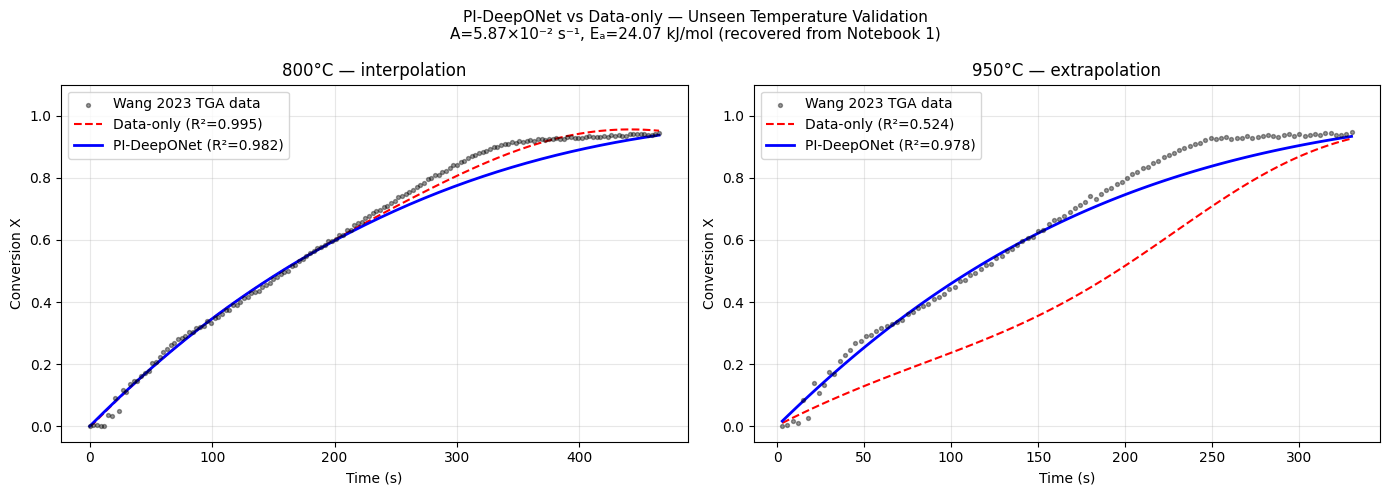

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
unseen_temps = [(1073.15, "800°C — interpolation"), (1223.15, "950°C — extrapolation")]

for ax, (T_K, title) in zip(axes, unseen_temps):
    t_A, X_A, X_true, l2_A, r2_A = validate_model_real(model_A, T_K, "Model A")
    t_C, X_C, _,      l2_C, r2_C = validate_model_real(model_C, T_K, "Model C")

    ax.scatter(t_A, X_true, color='black', s=8, alpha=0.4, label='Wang 2023 TGA data', zorder=5)
    ax.plot(t_A, X_A, 'r--', lw=1.5, label=f'Data-only (R²={r2_A:.3f})')
    ax.plot(t_C, X_C, 'b-',  lw=2,   label=f'PI-DeepONet (R²={r2_C:.3f})')

    ax.set_title(f'{title}', fontsize=12)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Conversion X')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

plt.suptitle('PI-DeepONet vs Data-only — Unseen Temperature Validation\n'
             'A=5.87×10⁻² s⁻¹, Eₐ=24.07 kJ/mol (recovered from Notebook 1)',
             fontsize=11)
plt.tight_layout()
plt.savefig('Fe2O3_PIDeepONet_validation.png', dpi=150, bbox_inches='tight')
plt.show()

[TRAIN] Model A T=750°C | Rel L2: 1.24% | R²: 0.9993 | MSE: 5.8787e-05
[TRAIN] Model C T=750°C | Rel L2: 2.83% | R²: 0.9962 | MSE: 3.0739e-04
[TRAIN] Model A T=850°C | Rel L2: 2.40% | R²: 0.9968 | MSE: 2.6718e-04
[TRAIN] Model C T=850°C | Rel L2: 4.06% | R²: 0.9908 | MSE: 7.6274e-04
[TRAIN] Model A T=900°C | Rel L2: 2.99% | R²: 0.9959 | MSE: 3.3998e-04
[TRAIN] Model C T=900°C | Rel L2: 6.33% | R²: 0.9818 | MSE: 1.5276e-03


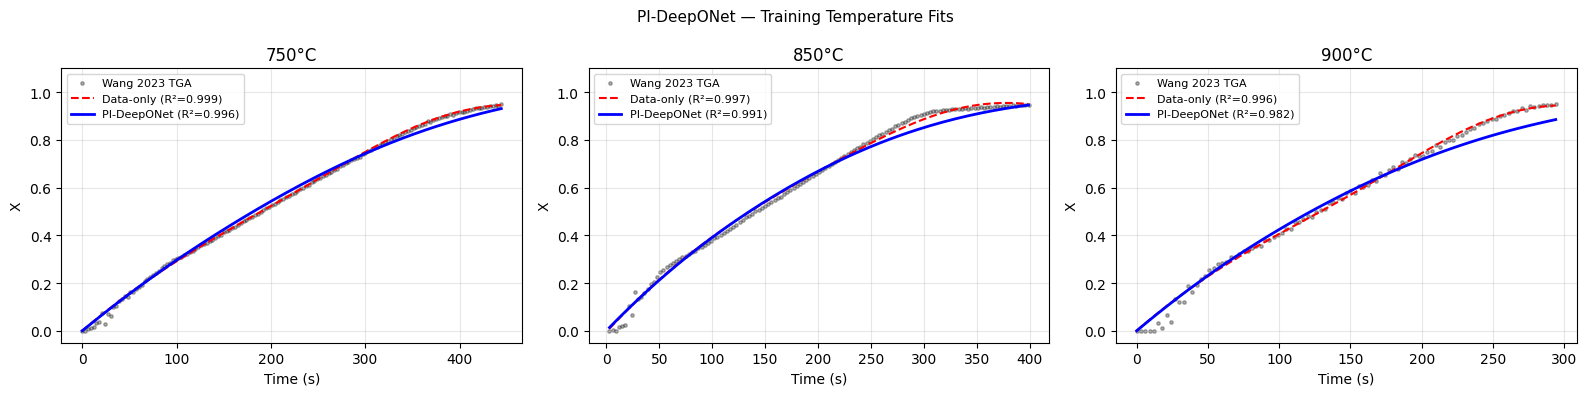

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
train_labels = ["750°C", "850°C", "900°C"]

for ax, T_K, lbl in zip(axes, train_temps_K, train_labels):
    t_A, X_A, X_true, l2_A, r2_A = validate_model_real(model_A, T_K, "Model A")
    t_C, X_C, _,      l2_C, r2_C = validate_model_real(model_C, T_K, "Model C")

    ax.scatter(t_A, X_true, color='black', s=6, alpha=0.3, label='Wang 2023 TGA')
    ax.plot(t_A, X_A, 'r--', lw=1.5, label=f'Data-only (R²={r2_A:.3f})')
    ax.plot(t_C, X_C, 'b-',  lw=2,   label=f'PI-DeepONet (R²={r2_C:.3f})')
    ax.set_title(lbl); ax.set_xlabel('Time (s)'); ax.set_ylabel('X')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.1)

plt.suptitle('PI-DeepONet — Training Temperature Fits', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
print("─" * 80)
print("FINAL COMPARISON TABLE — Fe₂O₃ Redox PINN vs DeepONet")
print("─" * 80)
print(f"{'Method':<35} {'750°C':>8} {'850°C':>8} {'900°C':>8} "
      f"{'800°C':>10} {'950°C':>10} {'Physics'}")
print("-" * 80)

results = {}
for T_K in train_temps_K + valid_temps_K:
    _, _, _, l2_A, r2_A = validate_model_real(model_A, T_K)
    _, _, _, l2_C, r2_C = validate_model_real(model_C, T_K)
    results[T_K] = {'A': r2_A, 'C': r2_C}

def r(T): return results[T]

print(f"{'Notebook 1 — Inverse PINN':<35} "
      f"{r(1023.15)['C']:>8.4f} {r(1123.15)['C']:>8.4f} {r(1173.15)['C']:>8.4f} "
      f"{0.9675:>10.4f} {0.2712:>10.4f}   {'Yes'}")

print(f"{'Data-only DeepONet (Model A)':<35} "
      f"{r(1023.15)['A']:>8.4f} {r(1123.15)['A']:>8.4f} {r(1173.15)['A']:>8.4f} "
      f"{r(1073.15)['A']:>10.4f} {r(1223.15)['A']:>10.4f}   {'No'}")

print(f"{'PI-DeepONet (Model C)':<35} "
      f"{r(1023.15)['C']:>8.4f} {r(1123.15)['C']:>8.4f} {r(1173.15)['C']:>8.4f} "
      f"{r(1073.15)['C']:>10.4f} {r(1223.15)['C']:>10.4f}   {'Yes'}")

print("-" * 80)
print("R² values. Notebook 1 at 800°C and 950°C from previous notebook.")
print("PI-DeepONet A and Ea: recovered from Notebook 1 inverse PINN")
print(f"  A = {A_recovered:.4e} s⁻¹,  Ea = {Ea_recovered/1000:.2f} kJ/mol")

────────────────────────────────────────────────────────────────────────────────
FINAL COMPARISON TABLE — Fe₂O₃ Redox PINN vs DeepONet
────────────────────────────────────────────────────────────────────────────────
Method                                 750°C    850°C    900°C      800°C      950°C Physics
--------------------------------------------------------------------------------
[TRAIN]  T=750°C | Rel L2: 1.24% | R²: 0.9993 | MSE: 5.8787e-05
[TRAIN]  T=750°C | Rel L2: 2.83% | R²: 0.9962 | MSE: 3.0739e-04
[TRAIN]  T=850°C | Rel L2: 2.40% | R²: 0.9968 | MSE: 2.6718e-04
[TRAIN]  T=850°C | Rel L2: 4.06% | R²: 0.9908 | MSE: 7.6274e-04
[TRAIN]  T=900°C | Rel L2: 2.99% | R²: 0.9959 | MSE: 3.3998e-04
[TRAIN]  T=900°C | Rel L2: 6.33% | R²: 0.9818 | MSE: 1.5276e-03
[VALID]  T=800°C | Rel L2: 2.93% | R²: 0.9953 | MSE: 4.0782e-04
[VALID]  T=800°C | Rel L2: 5.71% | R²: 0.9821 | MSE: 1.5450e-03
[VALID]  T=950°C | Rel L2: 29.04% | R²: 0.5236 | MSE: 4.0152e-02
[VALID]  T=950°C | Rel L2: 6.20% 

## 7. Computational Efficiency
One of the main advantages of operator learning is rapid inference. Unlike standard PINNs that must be optimized from scratch for every new physical parameter (e.g., a new temperature), the pre-trained PI-DeepONet can predict the entire dynamic curve for new temperatures almost instantaneously.

In [ ]:
import time
model_C.eval()
T_test_all = torch.linspace(0, 1, 100).reshape(-1, 1)
t_test_all = torch.linspace(0, 1, 200).reshape(-1, 1)

start = time.time()
with torch.no_grad():
    for T_val in T_test_all:
        _ = model_C.predict_single(T_val.squeeze(), t_test_all)
elapsed = (time.time() - start) * 1000
print(f"PI-DeepONet: 100 temperature predictions in {elapsed:.1f} ms")
print(f"Equivalent PINN retraining: ~100 × 10 min = ~17 hours")

PI-DeepONet: 100 temperature predictions in 14.3 ms
Equivalent PINN retraining: ~100 × 10 min = ~17 hours


## 8. Conclusion
- **Extrapolation**: The data-only model fails severely at 950°C, whereas the PI-DeepONet successfully extrapolates by anchoring its predictions to the underlying Arrhenius kinetics and Shrinking Core Model.
- **Speed**: Once trained, the PI-DeepONet acts as a highly efficient surrogate operator, performing evaluations orders of magnitude faster than retraining a standard PINN.
- **Data Sparsity**: PI-DeepONet maintains robust predictions even when trained on highly sparse experimental datasets, heavily utilizing the physics collocation points to fill the information gaps.